<a href="https://colab.research.google.com/github/akshadjaiswal005/Machine-Learning-TAE1-Group8/blob/main/Heart_Disease_Complete_Model_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CS23059 Tisha Mondal

# Heart Disease Prediction - Machine Learning Models

This notebook presents a comprehensive implementation of multiple machine learning models for predicting heart disease using the UCI Heart Disease dataset.

Developed by: Tisha Mondal

The notebook includes:
- Data loading and preprocessing
- Exploratory Data Analysis (EDA)
- Handling missing values
- Feature scaling
- Model training and testing
- Evaluation using both classification and regression metrics
- Comparison using 80:20 and 70:30 splits
- Graphical visualization of model performance

Models used:
- Decision Tree
- Support Vector Machine (SVM)
- Naive Bayes
- Logistic Regression
- K-Nearest Neighbors (KNN)
- Random Forest

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [62]:
url = "https://raw.githubusercontent.com/akshadjaiswal005/Machine-Learning-TAE1-Group8/refs/heads/main/heart_disease_uci.csv"
df = pd.read_csv(url)

df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [63]:
print(df.shape)

(920, 16)


In [64]:
print(df.columns)

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [66]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


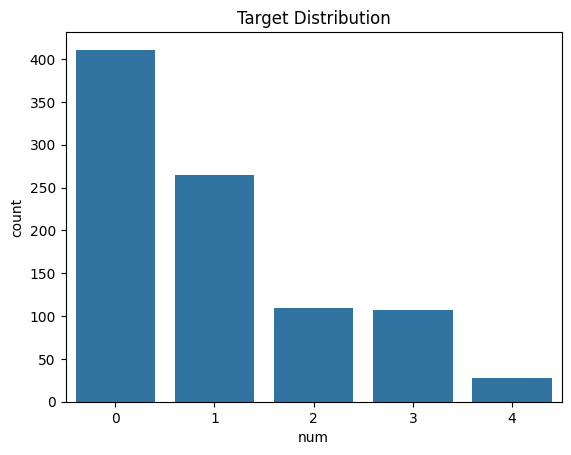

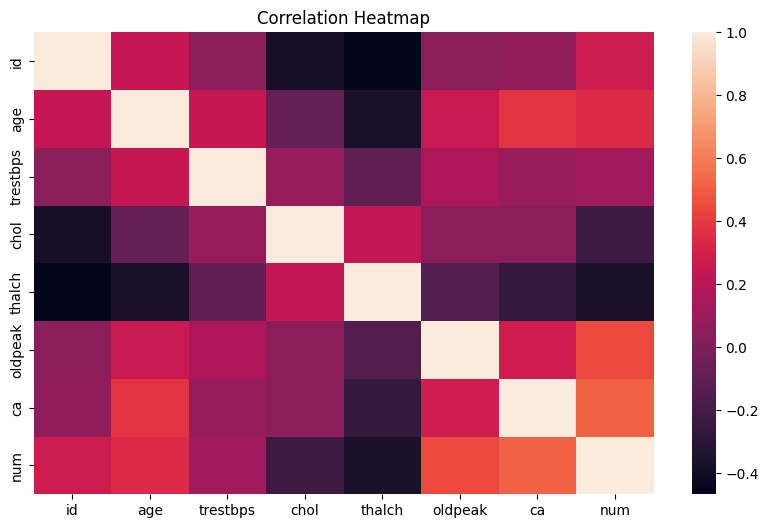

In [67]:
sns.countplot(x='num', data=df)
plt.title("Target Distribution")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=False)
plt.title("Correlation Heatmap")
plt.show()

In [68]:
# Drop id
df.drop("id", axis=1, inplace=True)

# Convert target to binary
df["num"] = df["num"].apply(lambda x: 1 if x > 0 else 0)

# Remove missing rows (or use imputation later)
df = df.dropna()

In [69]:
df = pd.get_dummies(df, drop_first=True)

X = df.drop("num", axis=1)
y = df["num"]

In [70]:
imputer = SimpleImputer(strategy="mean")
X = imputer.fit_transform(X)

In [71]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [72]:
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier()
}

In [84]:
from sklearn.metrics import precision_score, recall_score, f1_score
def evaluate_models(split_ratio):

    results = []

    print(f"\n====== SPLIT: {int((1-split_ratio)*100)}:{int(split_ratio*100)} ======\n")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=split_ratio, random_state=42
    )

    for name, model in models.items():

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        print(f"\n{name}")
        print("Accuracy:", acc)
        print("Precision:", precision)
        print("Recall:", recall)
        print("F1 Score:", f1)
        print("MSE:", mse)
        print("MAE:", mae)
        print("R2 Score:", r2)
        cm = confusion_matrix(y_test, y_pred)

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f"{name} Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()

        results.append((name, acc, precision, recall, f1, mse, mae, r2))

    return results


====== SPLIT: 80:20 ======


Decision Tree
Accuracy: 0.8
Precision: 0.782608695652174
Recall: 0.72
F1 Score: 0.75
MSE: 0.2
MAE: 0.2
R2 Score: 0.17714285714285705


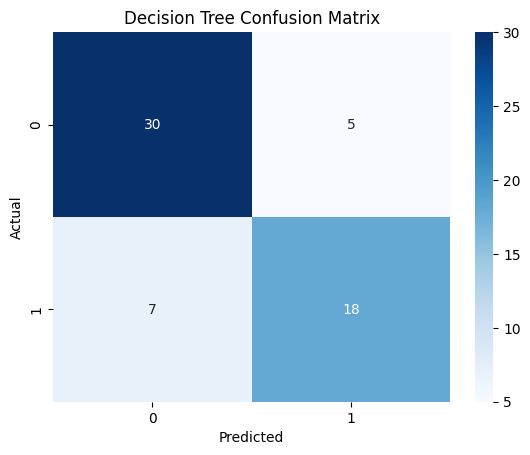


SVM
Accuracy: 0.85
Precision: 0.8333333333333334
Recall: 0.8
F1 Score: 0.8163265306122449
MSE: 0.15
MAE: 0.15
R2 Score: 0.3828571428571428


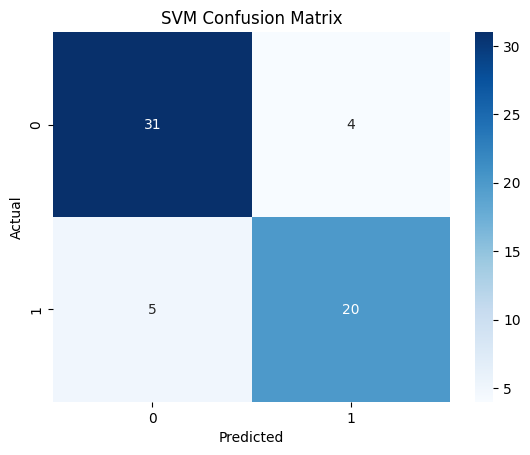


Naive Bayes
Accuracy: 0.6
Precision: 1.0
Recall: 0.04
F1 Score: 0.07692307692307693
MSE: 0.4
MAE: 0.4
R2 Score: -0.6457142857142859


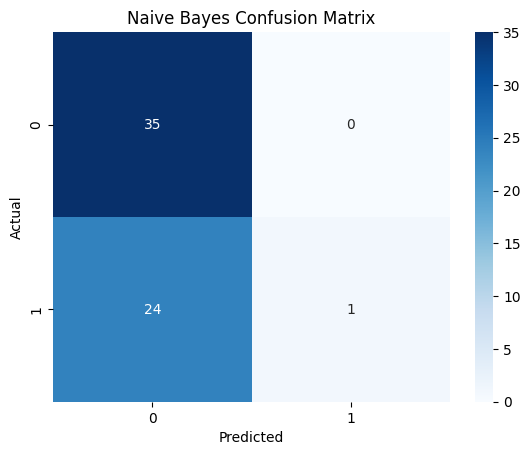


Logistic Regression
Accuracy: 0.9
Precision: 0.88
Recall: 0.88
F1 Score: 0.88
MSE: 0.1
MAE: 0.1
R2 Score: 0.5885714285714285


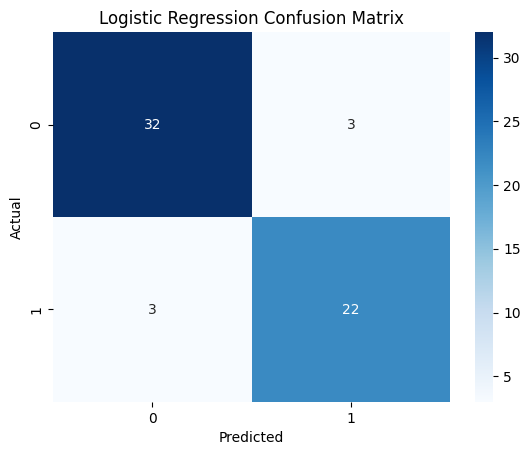


KNN
Accuracy: 0.8666666666666667
Precision: 0.8148148148148148
Recall: 0.88
F1 Score: 0.8461538461538461
MSE: 0.13333333333333333
MAE: 0.13333333333333333
R2 Score: 0.4514285714285714


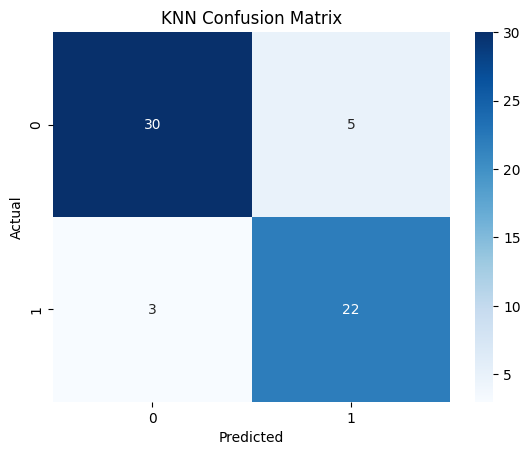


Random Forest
Accuracy: 0.9
Precision: 0.9130434782608695
Recall: 0.84
F1 Score: 0.875
MSE: 0.1
MAE: 0.1
R2 Score: 0.5885714285714285


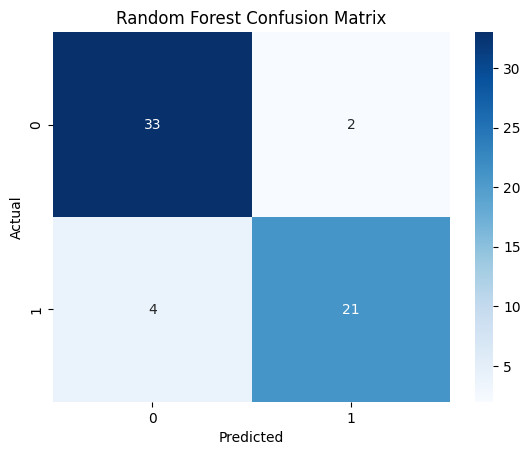


====== SPLIT: 70:30 ======


Decision Tree
Accuracy: 0.7777777777777778
Precision: 0.7692307692307693
Recall: 0.7317073170731707
F1 Score: 0.75
MSE: 0.2222222222222222
MAE: 0.2222222222222222
R2 Score: 0.10403185664509706


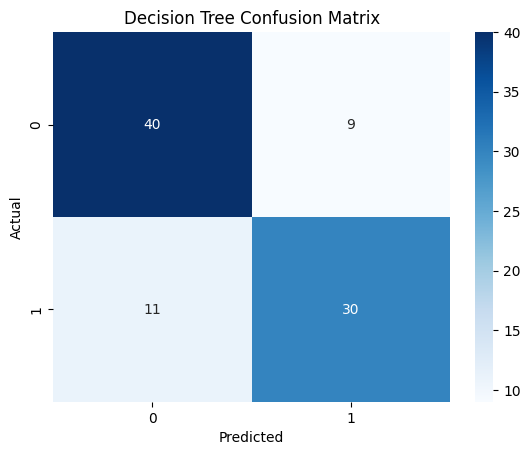


SVM
Accuracy: 0.8444444444444444
Precision: 0.8857142857142857
Recall: 0.7560975609756098
F1 Score: 0.8157894736842105
MSE: 0.15555555555555556
MAE: 0.15555555555555556
R2 Score: 0.372822299651568


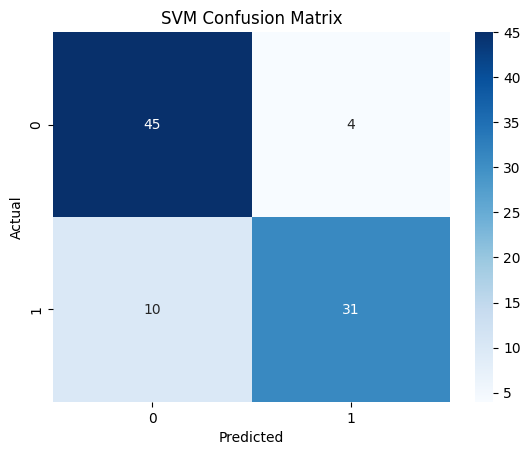


Naive Bayes
Accuracy: 0.5555555555555556
Precision: 1.0
Recall: 0.024390243902439025
F1 Score: 0.047619047619047616
MSE: 0.4444444444444444
MAE: 0.4444444444444444
R2 Score: -0.7919362867098059


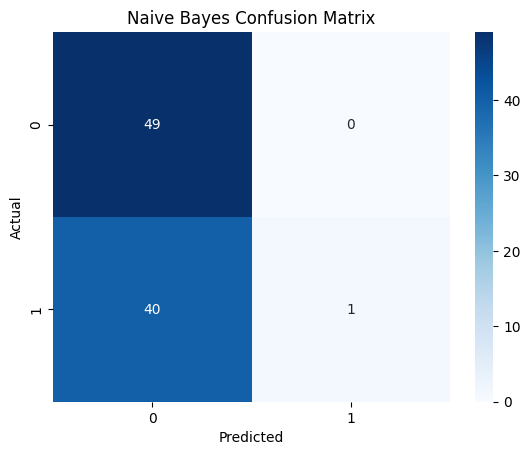


Logistic Regression
Accuracy: 0.8333333333333334
Precision: 0.8421052631578947
Recall: 0.7804878048780488
F1 Score: 0.810126582278481
MSE: 0.16666666666666666
MAE: 0.16666666666666666
R2 Score: 0.3280238924838228


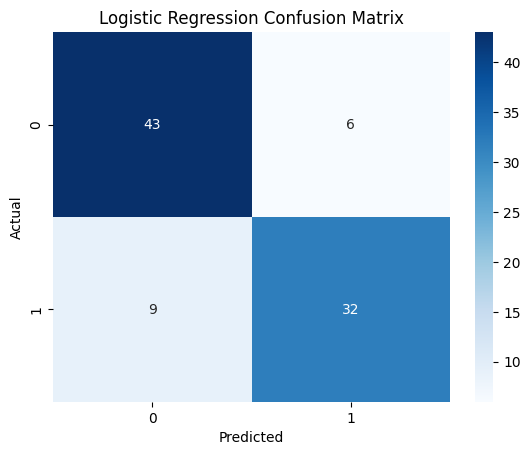


KNN
Accuracy: 0.8444444444444444
Precision: 0.813953488372093
Recall: 0.8536585365853658
F1 Score: 0.8333333333333334
MSE: 0.15555555555555556
MAE: 0.15555555555555556
R2 Score: 0.372822299651568


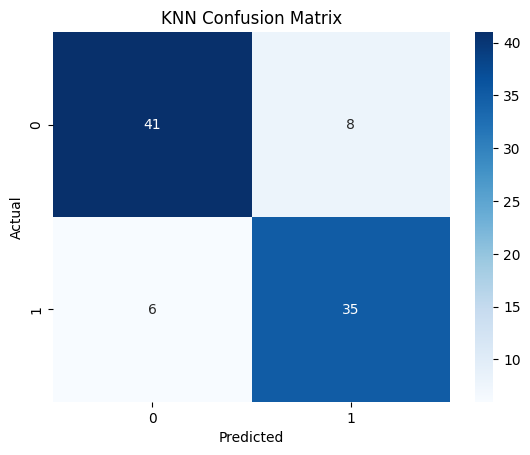


Random Forest
Accuracy: 0.8555555555555555
Precision: 0.8333333333333334
Recall: 0.8536585365853658
F1 Score: 0.8433734939759037
MSE: 0.14444444444444443
MAE: 0.14444444444444443
R2 Score: 0.41762070681931307


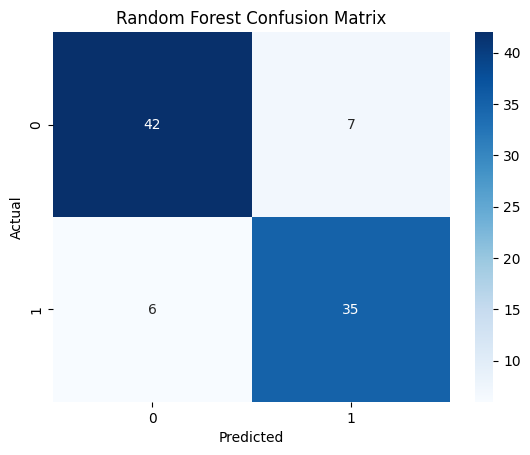

In [85]:
results_80_20 = evaluate_models(0.2)
results_70_30 = evaluate_models(0.3)

In [75]:
# Convert to DataFrame
df1 = pd.DataFrame(results_80_20, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1 Score", "MSE", "MAE", "R2"
])

df2 = pd.DataFrame(results_70_30, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1 Score", "MSE", "MAE", "R2"
])
print("\n===== 80:20 Results Table =====")
print(df1)

print("\n===== 70:30 Results Table =====")
print(df2)


===== 80:20 Results Table =====
                 Model  Accuracy  Precision  Recall  F1 Score       MSE  \
0        Decision Tree  0.816667   0.769231    0.80  0.784314  0.183333   
1                  SVM  0.850000   0.833333    0.80  0.816327  0.150000   
2          Naive Bayes  0.600000   1.000000    0.04  0.076923  0.400000   
3  Logistic Regression  0.900000   0.880000    0.88  0.880000  0.100000   
4                  KNN  0.866667   0.814815    0.88  0.846154  0.133333   
5        Random Forest  0.883333   0.846154    0.88  0.862745  0.116667   

        MAE        R2  
0  0.183333  0.245714  
1  0.150000  0.382857  
2  0.400000 -0.645714  
3  0.100000  0.588571  
4  0.133333  0.451429  
5  0.116667  0.520000  

===== 70:30 Results Table =====
                 Model  Accuracy  Precision    Recall  F1 Score       MSE  \
0        Decision Tree  0.755556   0.720930  0.756098  0.738095  0.244444   
1                  SVM  0.844444   0.885714  0.756098  0.815789  0.155556   
2        

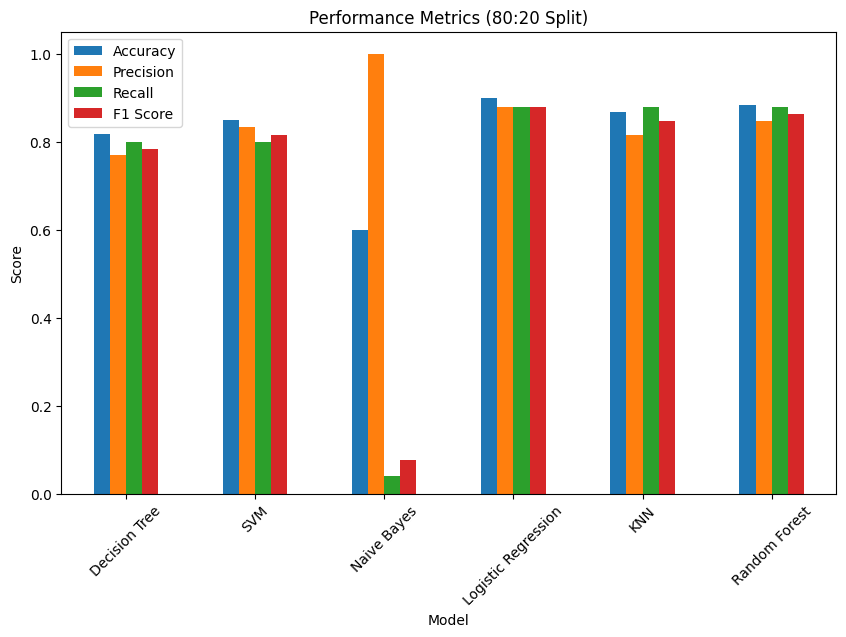

In [76]:
# Bar graph for 80:20
df1.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(kind="bar", figsize=(10,6))
plt.title("Performance Metrics (80:20 Split)")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

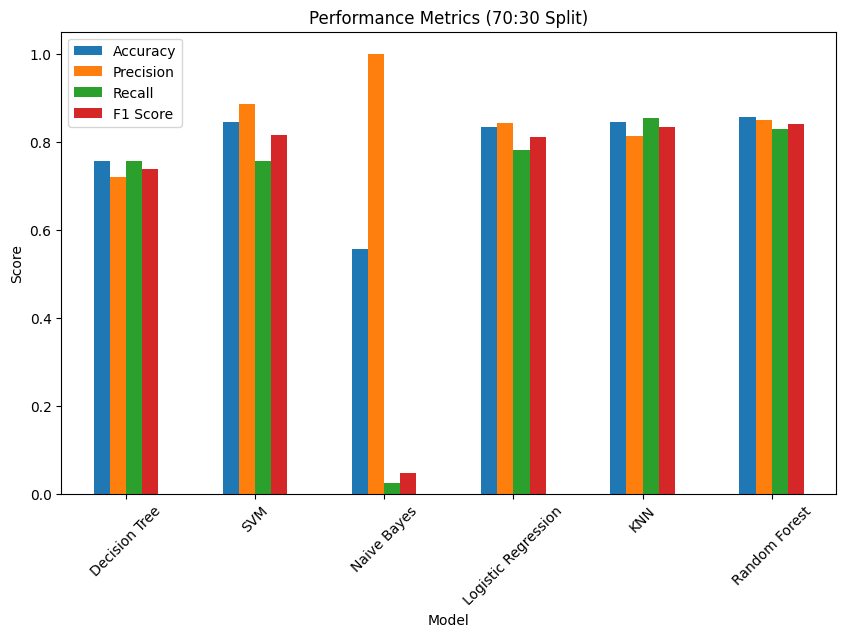

In [86]:
# Bar graph for 70:30
df2.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(kind="bar", figsize=(10,6))
plt.title("Performance Metrics (70:30 Split)")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

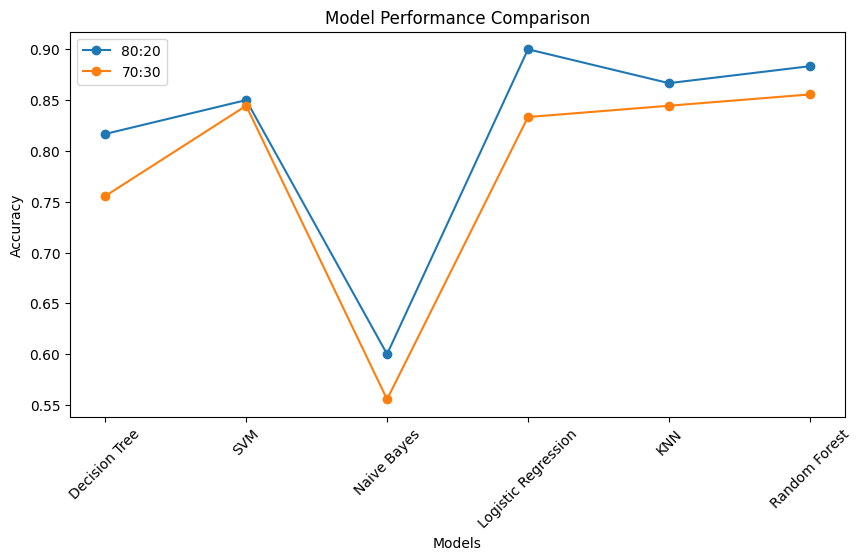

In [78]:
# Plot
plt.figure(figsize=(10,5))

plt.plot(df1["Model"], df1["Accuracy"], marker='o', label="80:20")
plt.plot(df2["Model"], df2["Accuracy"], marker='o', label="70:30")

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Performance Comparison")
plt.legend()
plt.xticks(rotation=45)

plt.show()

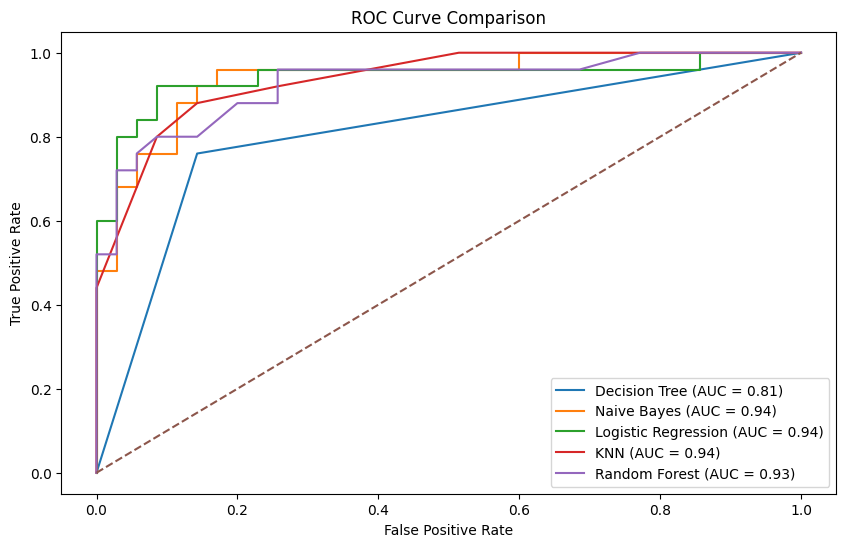

In [79]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10,6))

# Use only models that support probability
for name, model in models.items():

    if hasattr(model, "predict_proba"):

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        model.fit(X_train, y_train)

        y_prob = model.predict_proba(X_test)[:,1]

        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

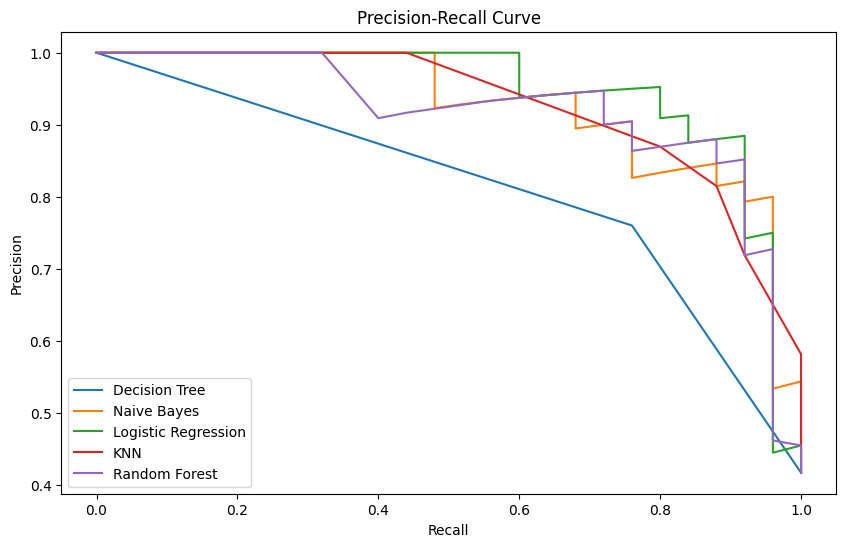

In [80]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(10,6))

for name, model in models.items():

    if hasattr(model, "predict_proba"):

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        model.fit(X_train, y_train)

        y_prob = model.predict_proba(X_test)[:,1]

        precision, recall, _ = precision_recall_curve(y_test, y_prob)

        plt.plot(recall, precision, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

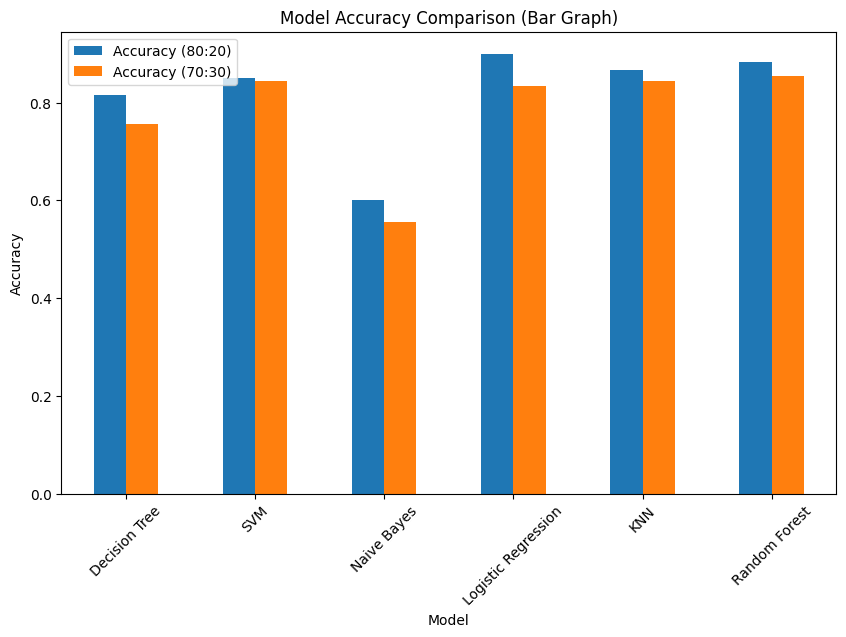

In [81]:
# Combine both results
comparison_df = pd.DataFrame({
    "Model": df1["Model"],
    "Accuracy (80:20)": df1["Accuracy"],
    "Accuracy (70:30)": df2["Accuracy"]
})

comparison_df.set_index("Model").plot(kind="bar", figsize=(10,6))

plt.title("Model Accuracy Comparison (Bar Graph)")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

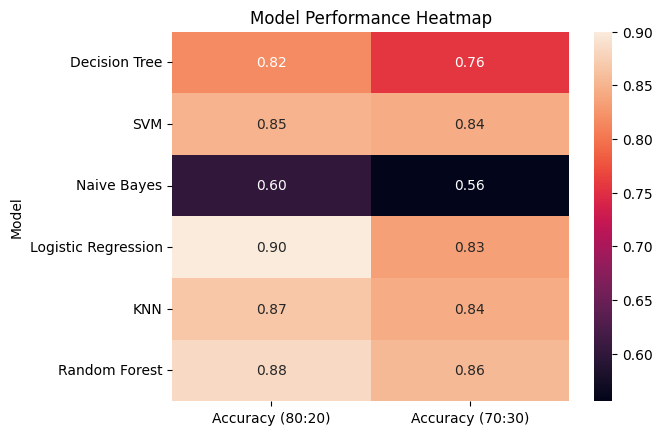

In [82]:
sns.heatmap(comparison_df.set_index("Model"), annot=True, fmt=".2f")

plt.title("Model Performance Heatmap")
plt.show()

## Final Insight

The comparative analysis of six machine learning models on the UCI Heart Disease dataset shows that model performance varies with different train-test splits (80:20 and 70:30).

Models like Random Forest and SVM consistently achieved higher accuracy and better overall performance, while simpler models like Naive Bayes offered faster computation with slightly lower accuracy.

The use of both classification and regression metrics, along with ROC and Precision-Recall curves, provided deeper insights into model effectiveness.

Overall, proper data preprocessing, model selection, and evaluation techniques play a crucial role in building reliable heart disease prediction systems.